In [30]:
import warnings
warnings.filterwarnings('ignore')

In [5]:
import kagglehub

path = kagglehub.dataset_download(
    "khaledhellmy/brain-breast-tumor",
    output_dir="../data"
)

print("Dataset downloaded to:", path)

100%|██████████| 222M/222M [04:49<00:00, 803kB/s]  

Extracting files...


Dataset downloaded to: ../data


In [8]:
import numpy as np
import pandas as pd


import os
for dirname,_,filenames in os.walk('../Data'):
    for filename in filenames:
        print(os.path.join(dirname,filename))

../Data\Brain scans\No tumor\Test\no501.jpg
../Data\Brain scans\No tumor\Test\no502.jpg
../Data\Brain scans\No tumor\Test\no503.jpg
../Data\Brain scans\No tumor\Test\no504.jpg
../Data\Brain scans\No tumor\Test\no505.jpg
../Data\Brain scans\No tumor\Test\no506.jpg
../Data\Brain scans\No tumor\Test\no507.jpg
../Data\Brain scans\No tumor\Test\no508.jpg
../Data\Brain scans\No tumor\Test\no509.jpg
../Data\Brain scans\No tumor\Test\no510.jpg
../Data\Brain scans\No tumor\Test\no511.jpg
../Data\Brain scans\No tumor\Test\no512.jpg
../Data\Brain scans\No tumor\Test\no513.jpg
../Data\Brain scans\No tumor\Test\no514.jpg
../Data\Brain scans\No tumor\Test\no515.jpg
../Data\Brain scans\No tumor\Test\no516.jpg
../Data\Brain scans\No tumor\Test\no517.jpg
../Data\Brain scans\No tumor\Test\no518.jpg
../Data\Brain scans\No tumor\Test\no519.jpg
../Data\Brain scans\No tumor\Test\no520.jpg
../Data\Brain scans\No tumor\Test\no521.jpg
../Data\Brain scans\No tumor\Test\no522.jpg
../Data\Brain scans\No tumor\Tes

In [9]:
print("Data Download")

Data Download


In [12]:
import pandas as pd
import os

base_paths = [
    ("../Data/Brain scans/No tumor/Train", "No tumor", "Train"),
    ("../Data/Brain scans/No tumor/Test", "No tumor", "Test"),

    ("../Data/Brain scans/Tumor/TRAIN", "Tumor", "Train"),
    ("../Data/Brain scans/Tumor/TEST", "Tumor", "Test"),

    ("../Data/Breast scans/benign/Train", "benign", "Train"),
    ("../Data/Breast scans/benign/Test", "benign", "Test"),

    ("../Data/Breast scans/malignant/Train", "malignant", "Train"),
    ("../Data/Breast scans/malignant/Test", "malignant", "Test"),

    ("../Data/Breast scans/normal/Train", "normal", "Train"),
    ("../Data/Breast scans/normal/Test", "normal", "Test")
]

import os
import pandas as pd

def collention_image_data():
    image_paths = []
    labels = []
    splits = []

    for path, label, split in base_paths:

        # Check whether directory exists
        if not os.path.exists(path):
            print(f"Warning: Directory {path} does not exist.")
            continue

        # Collect images
        for filename in os.listdir(path):

            img_path = os.path.join(path, filename)

            # Only process image files
            if filename.lower().endswith((".jpg", ".jpeg", ".png")):

                image_paths.append(img_path)
                labels.append(label)
                splits.append(split)

    return image_paths, labels, splits


image_paths, labels, splits = collention_image_data()

df = pd.DataFrame({
    "Image_Path": image_paths,
    "Label": labels,
    "Split": splits
})

print("Total images:", len(df))
print(df.head())

Total images: 2645
                                     Image_Path     Label  Split
0    ../Data/Brain scans/No tumor/Train\no0.jpg  No tumor  Train
1    ../Data/Brain scans/No tumor/Train\no1.jpg  No tumor  Train
2   ../Data/Brain scans/No tumor/Train\no10.jpg  No tumor  Train
3  ../Data/Brain scans/No tumor/Train\no100.jpg  No tumor  Train
4  ../Data/Brain scans/No tumor/Train\no101.jpg  No tumor  Train


In [13]:
df

,Image_Path,Label,Split
0,../Data/Brain scans/No tumor/Train\no0.jpg,No tumor,Train
1,../Data/Brain scans/No tumor/Train\no1.jpg,No tumor,Train
2,../Data/Brain scans/No tumor/Train\no10.jpg,No tumor,Train
3,../Data/Brain scans/No tumor/Train\no100.jpg,No tumor,Train
4,../Data/Brain scans/No tumor/Train\no101.jpg,No tumor,Train
...,...,...,...
2640,../Data/Breast scans/normal/Test\normal (129).png,normal,Test
2641,../Data/Breast scans/normal/Test\normal (130).png,normal,Test
2642,../Data/Breast scans/normal/Test\normal (131).png,normal,Test
2643,../Data/Breast scans/normal/Test\normal (132).png,normal,Test


In [14]:
df=df[['Image_Path','Label']]

In [15]:
df

,Image_Path,Label
0,../Data/Brain scans/No tumor/Train\no0.jpg,No tumor
1,../Data/Brain scans/No tumor/Train\no1.jpg,No tumor
2,../Data/Brain scans/No tumor/Train\no10.jpg,No tumor
3,../Data/Brain scans/No tumor/Train\no100.jpg,No tumor
4,../Data/Brain scans/No tumor/Train\no101.jpg,No tumor
...,...,...
2640,../Data/Breast scans/normal/Test\normal (129).png,normal
2641,../Data/Breast scans/normal/Test\normal (130).png,normal
2642,../Data/Breast scans/normal/Test\normal (131).png,normal
2643,../Data/Breast scans/normal/Test\normal (132).png,normal


## EDA - EXPLORATORY DATA ANALYSIS

In [16]:
df.shape

(2645, 2)

In [17]:
df.columns

Index(['Image_Path', 'Label'], dtype='str')

In [18]:
df.duplicated().sum()

np.int64(0)

In [19]:
df.isnull().sum()

Image_Path    0
Label         0
dtype: int64

In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2645 entries, 0 to 2644
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Image_Path  2645 non-null   str  
 1   Label       2645 non-null   str  
dtypes: str(2)
memory usage: 183.2 KB


In [21]:
df['Label'].unique()

<ArrowStringArray>
['No tumor', 'Tumor', 'benign', 'malignant', 'normal']
Length: 5, dtype: str

'No tumor', 'Tumor', 'benign', 'malignant', 'normal'

MULTI CLASS CLASSIFICATION

CHECK COUNT 

In [22]:
df['Label'].value_counts()

Label
benign       891
No tumor     601
Tumor        600
malignant    420
normal       133
Name: count, dtype: int64

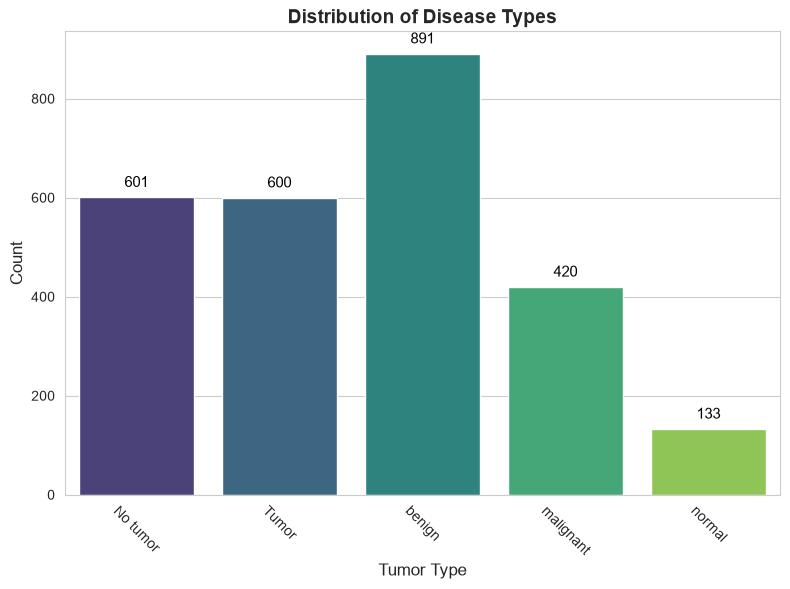

In [31]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style('whitegrid')

fig,ax=plt.subplots(figsize=(8,6))
sns.countplot(data=df,x='Label',palette='viridis',ax=ax)
ax.set_title("Distribution of Disease Types",fontsize=14,fontweight='bold')
ax.set_xlabel('Tumor Type',fontsize=12)
ax.set_ylabel('Count',fontsize=12)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x()+p.get_width()/2.,p.get_height()),
                ha='center',va='bottom',fontsize=11,color='black',
                xytext=(0,5),textcoords='offset points')
plt.xticks(rotation=-45)
plt.tight_layout()
plt.show()

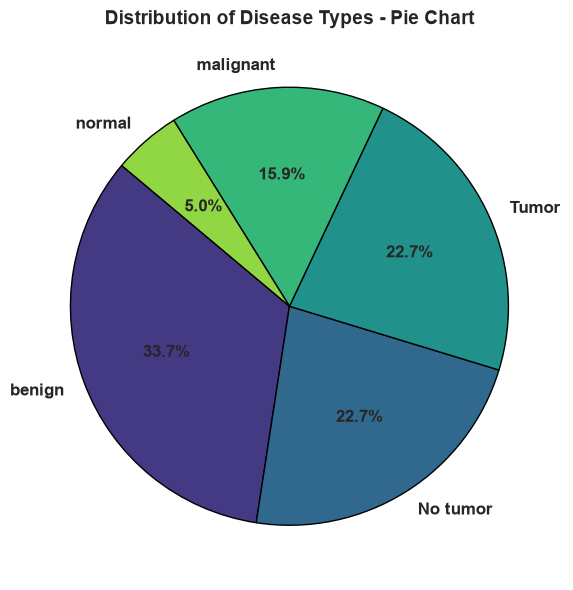

In [38]:
labels_counts=df['Label'].value_counts()
fig,ax=plt.subplots(figsize=(8,6))
colors=sns.color_palette('viridis',len(labels_counts))
ax.pie(labels_counts,labels=labels_counts.index,autopct='%1.1f%%',
       startangle=140,colors=colors,textprops={'fontsize':12,'weight':'bold'},
       wedgeprops={'edgecolor':'black','linewidth':1})
ax.set_title('Distribution of Disease Types - Pie Chart',fontsize=14,fontweight='bold')
plt.tight_layout()
plt.show()


VISUALIZE THE IMAGES

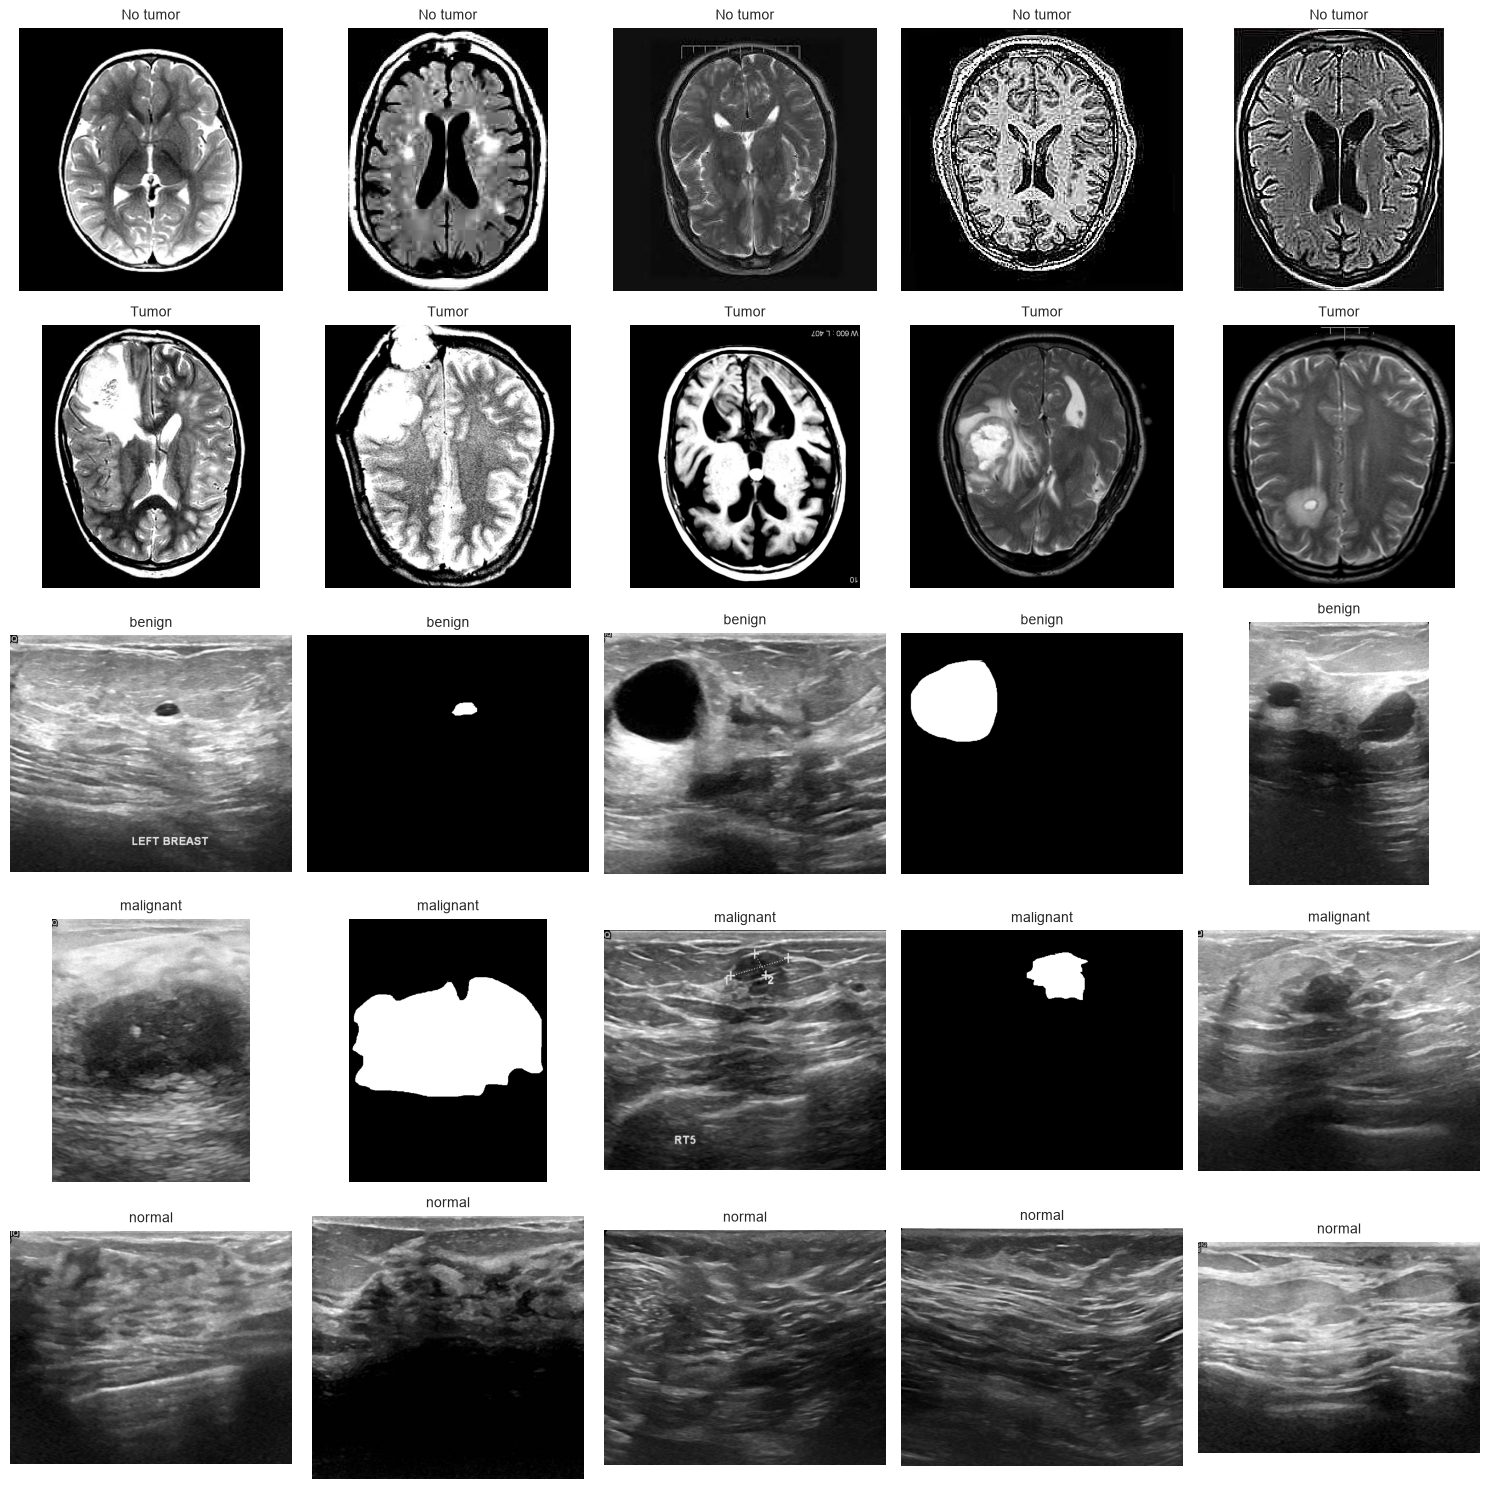

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import cv2

categories = df['Label'].unique()

n_cols = 5
n_rows = len(categories)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 3))
if n_rows == 1:
    axes = [axes]
else:
    axes = axes.flatten()

plot_idx = 0

for category in categories:
    category_paths = df[df['Label'] == category]['Image_Path'].head(5).tolist()
    
    for img_path in category_paths:
        if plot_idx < len(axes):
            try:
                img = cv2.imread(img_path)
                if img is None:
                    axes[plot_idx].text(0.5, 0.5, 'Image not found', 
                                        ha='center', va='center', transform=axes[plot_idx].transAxes)
                else:
                    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                    axes[plot_idx].imshow(img)
                axes[plot_idx].set_title(category, fontsize=10)
                axes[plot_idx].axis('off')
            except:
                axes[plot_idx].text(0.5, 0.5, 'Error loading', 
                                    ha='center', va='center', transform=axes[plot_idx].transAxes)
            plot_idx += 1
    
    while len(category_paths) < 5 and plot_idx < len(axes):
        axes[plot_idx].text(0.5, 0.5, 'No image', 
                            ha='center', va='center', transform=axes[plot_idx].transAxes)
        axes[plot_idx].set_title(category, fontsize=10)
        axes[plot_idx].axis('off')
        plot_idx += 1

plt.tight_layout()
plt.show()

BALANCING THE DATA

In [48]:
from sklearn.utils import resample

categories = df['Label'].unique()

max_count = df['Label'].value_counts().max()

df_balanced = pd.DataFrame()

for category in categories:
    df_category = df[df['Label'] == category]
    df_category_resampled = resample(df_category, 
                                    replace=True, 
                                    n_samples=max_count, 
                                    random_state=42)
    df_balanced = pd.concat([df_balanced, df_category_resampled], ignore_index=True)

df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print(df_balanced['Label'].value_counts())

df = df_balanced

Label
normal       891
Tumor        891
malignant    891
benign       891
No tumor     891
Name: count, dtype: int64


In [49]:
df

,Image_Path,Label
0,../Data/Breast scans/normal/Test\normal (125).png,normal
1,../Data/Brain scans/Tumor/TRAIN\y465.jpg,Tumor
2,../Data/Breast scans/malignant/Test\malignant ...,malignant
3,../Data/Breast scans/malignant/Train\malignant...,malignant
4,../Data/Breast scans/benign/Train\benign (135)...,benign
...,...,...
4450,../Data/Breast scans/benign/Train\benign (60).png,benign
4451,../Data/Brain scans/Tumor/TRAIN\y230.jpg,Tumor
4452,../Data/Breast scans/normal/Train\normal (37).png,normal
4453,../Data/Breast scans/benign/Test\benign (426)_...,benign


MODEL TRAINING 

BASELINE CNN MODEL

In [50]:
import pandas as pd
import numpy as np
import cv2
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

In [55]:
IMG_SIZE = 128

def load_images(df):
    X = []
    for path in df["Image_Path"]:
        img = cv2.imread(path)
        img = cv2.resize(img,(IMG_SIZE,IMG_SIZE))
        img = img/255.0
        X.append(img)
    return np.array(X)

In [56]:
x=load_images(df)

y=pd.get_dummies(df['Label']).values
label_names=pd.get_dummies(df['Label']).columns

In [57]:
x_train,x_test,y_train,y_test=train_test_split(
    x,y,test_size=0.2,random_state=42
)

In [58]:
print(x_train.shape)
print(y_train.shape)

(3564, 128, 128, 3)
(3564, 5)


In [60]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Flatten,Dense,Dropout

In [61]:
cnn_model=Sequential([
    Conv2D(32,(3,3),activation='relu',input_shape=(128,128,3)),
    MaxPooling2D(2,2),

    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D(3,3),

    Conv2D(128,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128,activation='relu'),
    Dropout(0.5),

    Dense(len(label_names),activation='softmax')
])

In [62]:
cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 20, 20, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 18, 18, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 9, 9, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 10368)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,327,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,421,125 (5.42 MB)

 Trainable params: 1,421,125 (5.42 MB)

 Non-trainable params: 0 (0.00 B)

In [63]:
cnn_history=cnn_model.fit(
    x_train,y_train,
    epochs=10,
    batch_size=32,
    validation_data=(x_test,y_test)
)

Epoch 1/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 16s 116ms/step - accuracy: 0.6097 - loss: 0.8756 - val_accuracy: 0.7363 - val_loss: 0.5851
Epoch 2/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 12s 107ms/step - accuracy: 0.7421 - loss: 0.5984 - val_accuracy: 0.8395 - val_loss: 0.4767
Epoch 3/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 13s 113ms/step - accuracy: 0.8443 - loss: 0.4005 - val_accuracy: 0.8844 - val_loss: 0.3402
Epoch 4/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 12s 108ms/step - accuracy: 0.8824 - loss: 0.3004 - val_accuracy: 0.8945 - val_loss: 0.3210
Epoch 5/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 12s 104ms/step - accuracy: 0.9329 - loss: 0.1998 - val_accuracy: 0.9327 - val_loss: 0.1936
Epoch 6/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 12s 104ms/step - accuracy: 0.9492 - loss: 0.1472 - val_accuracy: 0.9461 - val_loss: 0.2002
Epoch 7/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 12s 106ms/step - accuracy: 0.9646 - loss: 0.1156 - val_accuracy: 0.9506 - val_loss: 0.1939
Epoch 8/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 12s 105ms/step - accuracy: 0.9762 - loss: 0

In [64]:
cnn_model.save('../models/baseline_cnn.keras')
cnn_model.save('../models/baseline_cnn.h5')